<a href="https://colab.research.google.com/github/brvndon266/MAE249_Soft_Robotics/blob/main/Homework_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

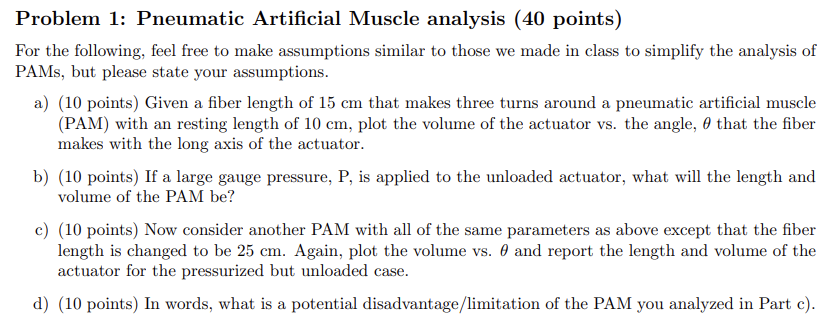

Problem 1 - Part A
---

Resting angle θ_rest = 48.1897°
Resting volume V_rest = 0.000011 m³


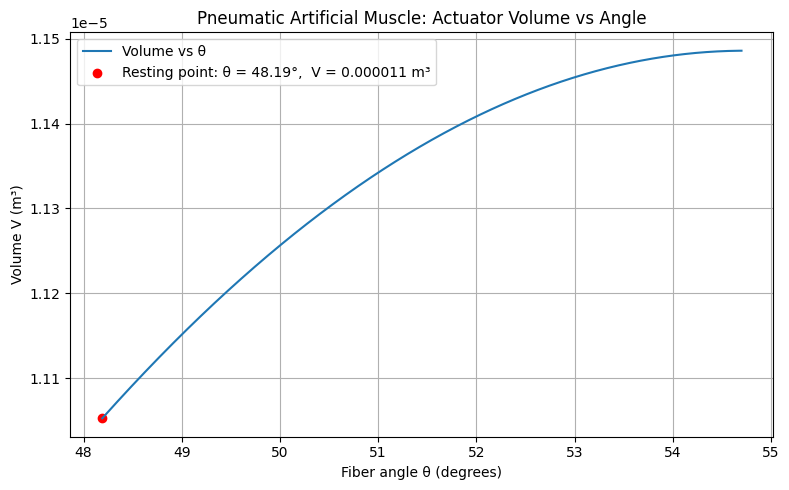

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- Given parameters (Part a) ---
b = 0.15      # fiber length [m]
n = 3         # number of turns
L_rest = 0.1  # resting length [m]
pi = np.pi

# --- Volume formula ---
# V(θ) = (b^3 / (4πn^2)) * sin^2(θ) * cos(θ)
def V_of_theta(b, n, theta):
    return (b**3 / (4 * pi * n**2)) * (np.sin(theta)**2) * np.cos(theta)

# --- Resting angle (from L = b cosθ) ---
theta_rest = np.arccos(L_rest / b)  # radians
V_rest = V_of_theta(b, n, theta_rest)

# --- Define θ range: from θ_rest to θ_max (54.7°) ---
theta_max_deg = 54.7
theta_max = np.radians(theta_max_deg)
theta = np.linspace(theta_rest, theta_max, 1000)

# --- Compute V(θ) ---
V = V_of_theta(b, n, theta)

# --- Print results ---
print(f"Resting angle θ_rest = {np.degrees(theta_rest):.4f}°")
print(f"Resting volume V_rest = {V_rest:.6f} m³")

# --- Plot Volume vs θ ---
plt.figure(figsize=(8,5))
plt.plot(np.degrees(theta), V, label='Volume vs θ')
plt.scatter(np.degrees(theta_rest), V_rest, color='red',
            label=f"Resting point: θ = {np.degrees(theta_rest):.2f}°,  V = {V_rest:.6f} m³")
plt.xlabel("Fiber angle θ (degrees)")
plt.ylabel("Volume V (m³)")
plt.title("Pneumatic Artificial Muscle: Actuator Volume vs Angle")
plt.grid(True)
plt.legend(loc='best')
plt.tight_layout()
plt.show()


Problem 1 - Part C
---


Resting angle θ_rest = 66.4218°
Resting volume V_rest = 0.000046 m³


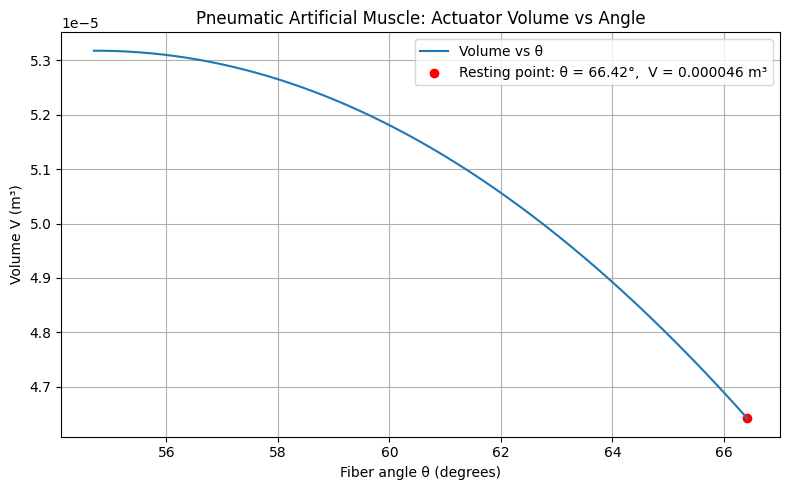

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# --- Given parameters (Part a) ---
b = 0.25      # fiber length [m]
n = 3         # number of turns
L_rest = 0.1  # resting length [m]
pi = np.pi

# --- Volume formula ---
# V(θ) = (b^3 / (4πn^2)) * sin^2(θ) * cos(θ)
def V_of_theta(b, n, theta):
    return (b**3 / (4 * pi * n**2)) * (np.sin(theta)**2) * np.cos(theta)

# --- Resting angle (from L = b cosθ) ---
theta_rest = np.arccos(L_rest / b)  # radians
V_rest = V_of_theta(b, n, theta_rest)

# --- Define θ range: from θ_rest to θ_max (54.7°) ---
theta_max_deg = 54.7
theta_max = np.radians(theta_max_deg)
theta = np.linspace(theta_rest, theta_max, 1000)

# --- Compute V(θ) ---
V = V_of_theta(b, n, theta)

# --- Print results ---
print(f"Resting angle θ_rest = {np.degrees(theta_rest):.4f}°")
print(f"Resting volume V_rest = {V_rest:.6f} m³")

# --- Plot Volume vs θ ---
plt.figure(figsize=(8,5))
plt.plot(np.degrees(theta), V, label='Volume vs θ')
plt.scatter(np.degrees(theta_rest), V_rest, color='red',
            label=f"Resting point: θ = {np.degrees(theta_rest):.2f}°,  V = {V_rest:.6f} m³")
plt.xlabel("Fiber angle θ (degrees)")
plt.ylabel("Volume V (m³)")
plt.title("Pneumatic Artificial Muscle: Actuator Volume vs Angle")
plt.grid(True)
plt.legend(loc='best')
plt.tight_layout()
plt.show()


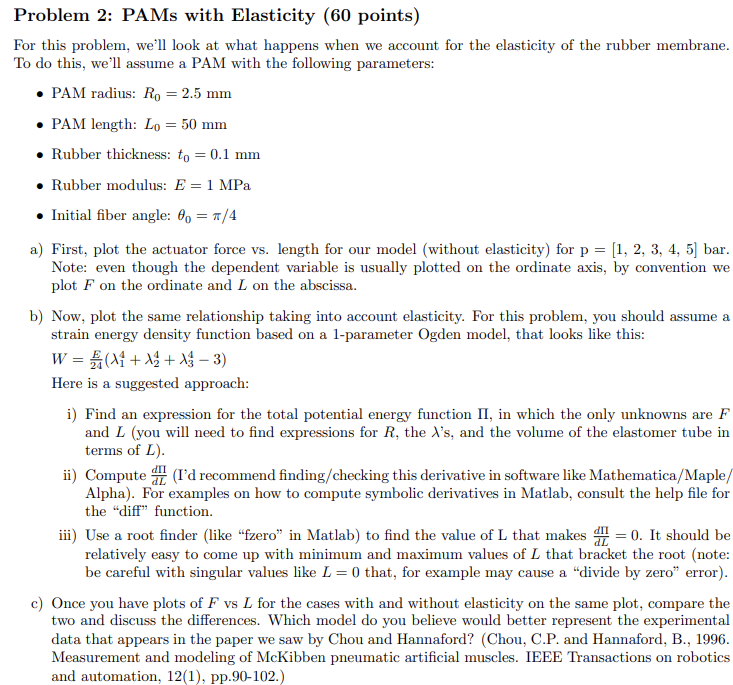

Problem 2 - Part A
---

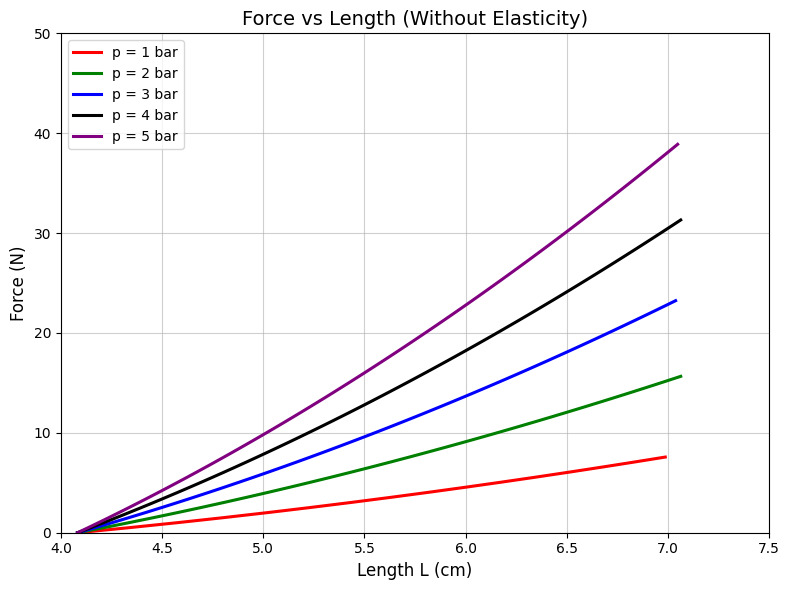

L_low = 5.0000e-04 m = 0.050 cm
L_high = 7.0640e-02 m = 7.064 cm


In [23]:
import numpy as np
import matplotlib.pyplot as plt

# --- Given parameters ---
E = 1e6            # not used directly here
R0 = 2.5e-3        # m
t0 = 0.1e-3        # m
L0 = 50e-3         # m
theta0 = np.pi / 4

# Derived geometry
b = L0 / np.cos(theta0)
n = b * np.sqrt(1 - (L0**2 / b**2)) / (2 * np.pi * R0)

# Force / Pressure ranges
N = 100
Fmin = 0.0
Fmax = 50.0
Force = np.linspace(Fmin, Fmax, N)      # force vector (N)
Pressures = np.array([1e5, 2e5, 3e5, 4e5, 5e5])  # Pa

# Length bounds (same as MATLAB snippet)
L_low = 0.01 * L0
L_high = 0.999 * b

plt.figure(figsize=(8, 6))

# Custom color list: red, green, blue, black, pink
custom_colors = ['red', 'green', 'blue', 'black', 'purple']

for j, p in enumerate(Pressures):
    A = (p * b**2) / (4 * np.pi * n**2)  # coefficient in F = A*(3L^2/b^2 - 1)

    Lvals = np.zeros(N)
    for i, F_target in enumerate(Force):
        # Analytical inversion: L = b * sqrt((F/A + 1) / 3)
        inside = (F_target / A) + 1.0
        if inside >= 0:
            L_calc = b * np.sqrt(inside / 3.0)
        else:
            L_calc = 0.0

        # enforce bounds
        if (L_calc >= L_low) and (L_calc <= L_high):
            Lvals[i] = L_calc
        else:
            Lvals[i] = 0.0

    # Plot only valid points
    valid_mask = Lvals > 0
    plt.plot(
        Lvals[valid_mask] * 1e2,
        Force[valid_mask],
        color=custom_colors[j],
        lw=2.2,
        label=f"p = {p/1e5:.0f} bar"
    )

plt.xlabel("Length L (cm)", fontsize=12)
plt.ylabel("Force (N)", fontsize=12)
plt.title("Force vs Length (Without Elasticity)", fontsize=14)
plt.ylim(0, 50)
plt.xlim(4, 7.5)
plt.grid(True, linestyle="-", alpha=0.6)
plt.legend(loc="best", fontsize=10)
plt.tight_layout()
plt.show()

# Print debug info
print(f"L_low = {L_low:.4e} m = {L_low*100:.3f} cm")
print(f"L_high = {L_high:.4e} m = {L_high*100:.3f} cm")


Problem 2 - Part C
---

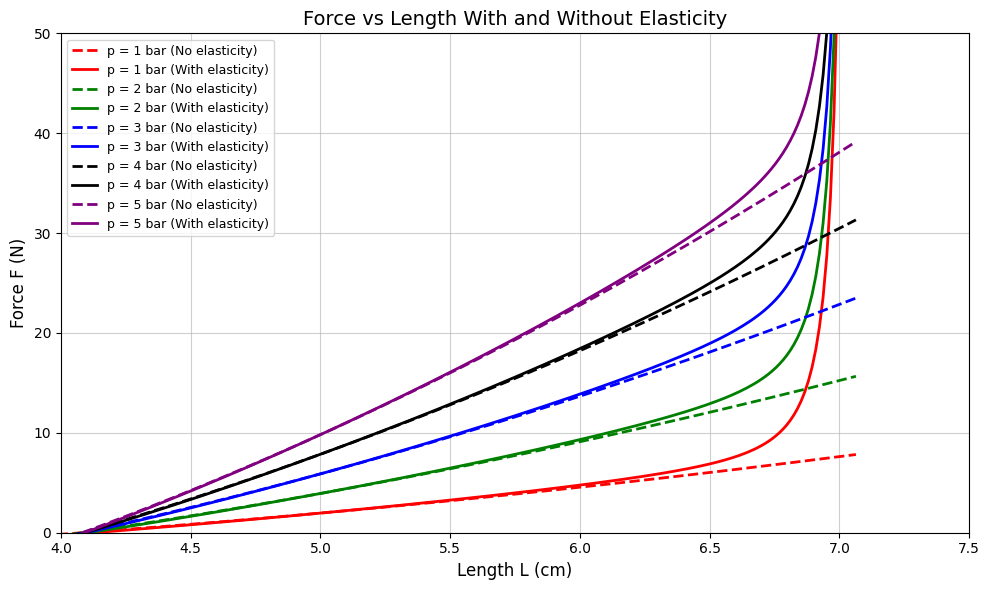

L_low = 5.0000e-04 m = 0.050 cm
L_high = 7.0640e-02 m = 7.064 cm


In [26]:
import numpy as np
import matplotlib.pyplot as plt

# --- Given parameters ---
E = 1e6            # Pa (Young's modulus)
R0 = 2.5e-3        # m
t0 = 0.1e-3        # m
L0 = 50e-3         # m
theta0 = np.pi / 4

# Derived geometry
b = L0 / np.cos(theta0)
n = b * np.sqrt(1 - (L0**2 / b**2)) / (2 * np.pi * R0)

# Pressure values (Pa)
Pressures = np.array([1e5, 2e5, 3e5, 4e5, 5e5])  # 1 to 5 bar

# Custom colors: red, green, blue, black, pink
custom_colors = ['red', 'green', 'blue', 'black', 'purple']

# Length range
N = 500
L_low = 0.01 * L0
L_high = 0.999 * b
Lvals = np.linspace(L_low, L_high, N)

# Plot setup
plt.figure(figsize=(10, 6))

for j, p in enumerate(Pressures):
    color = custom_colors[j]

    # --- Original force model (no elasticity) ---
    A = (p * b**2) / (4 * np.pi * n**2)
    F_orig = A * (3 * Lvals**2 / b**2 - 1)

    # --- Elasticity-corrected model ---
    term1 = (Lvals**2 * p) / (2 * n**2 * np.pi)
    term2 = (p * (b**2 - Lvals**2)) / (4 * n**2 * np.pi)

    elastic_prefactor = (1 / 12) * L0 * np.pi * R0 * t0 * E
    term3a = (2 * Lvals) / (L0**2)
    term3b = Lvals / (2 * n**2 * np.pi**2 * R0**2)
    denom1 = b**4 * Lvals * (1 - (Lvals**2 / b**2))**2
    denom2 = b**2 * Lvals**3 * (1 - (Lvals**2 / b**2))
    term3c = (8 * L0**2 * n**2 * np.pi**2 * R0**2) / denom1
    term3d = (8 * L0**2 * n**2 * np.pi**2 * R0**2) / denom2

    F_elastic = term1 - term2 + elastic_prefactor * (term3a - term3b + term3c - term3d)

    # Plot both curves
    plt.plot(Lvals * 1e2, F_orig, linestyle="--", color=color, lw=2,
             label=f"p = {p/1e5:.0f} bar (No elasticity)")
    plt.plot(Lvals * 1e2, F_elastic, linestyle="-", color=color, lw=2,
             label=f"p = {p/1e5:.0f} bar (With elasticity)")

# Final plot settings
plt.xlabel("Length L (cm)", fontsize=12)
plt.ylabel("Force F (N)", fontsize=12)
plt.title("Force vs Length With and Without Elasticity", fontsize=14)
plt.ylim(0, 50)
plt.xlim(4, 7.5)
plt.grid(True, linestyle="-", alpha=0.6)
plt.legend(loc="best", fontsize=9)
plt.tight_layout()
plt.show()

# Print debug info
print(f"L_low = {L_low:.4e} m = {L_low*100:.3f} cm")
print(f"L_high = {L_high:.4e} m = {L_high*100:.3f} cm")
